In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import json 
import os
import cv2
from tqdm import tqdm

In [109]:
measurement_dir_names = ['FHL', 'MLML', 'SSL'] ## names of the folders inside the measurement directory
measurement_dirs = []

verbose = True

id_dirs = []
ids = []
lab_names = []

for measurement_dir_name in measurement_dir_names:
    if verbose:
        print(measurement_dir_name)
    measurement_dir = f'../../measurements/{measurement_dir_name}/knownID'
    if os.path.exists(measurement_dir) != True:
        print(f'measurement dir {measurement_dir} DOES NOT EXIST!')
        print(f'please check that you have set up the notebook correctly')
    
    for dir_name in os.listdir(measurement_dir):
        dir_path = os.path.join(measurement_dir, dir_name)
        if os.path.isdir(dir_path):
            if dir_name != 'inputIDcode': ## remove development folder
                id_dirs.append(dir_path)
                if verbose:
                    print(dir_path)
                ids.append(dir_name)
                lab_names.append(measurement_dir_name)

FHL
../../measurements/FHL/knownID\Aster
../../measurements/FHL/knownID\Beryl
../../measurements/FHL/knownID\Bigbee
../../measurements/FHL/knownID\Byul
../../measurements/FHL/knownID\Chrissy
../../measurements/FHL/knownID\Coraline
../../measurements/FHL/knownID\Draco
../../measurements/FHL/knownID\Gen
../../measurements/FHL/knownID\Ginro
../../measurements/FHL/knownID\Hannibal
../../measurements/FHL/knownID\Hoshi
../../measurements/FHL/knownID\James
../../measurements/FHL/knownID\Jesse
../../measurements/FHL/knownID\Joe Hendry
../../measurements/FHL/knownID\Kaseki
../../measurements/FHL/knownID\Kinro
../../measurements/FHL/knownID\Kira
../../measurements/FHL/knownID\Kohaku
../../measurements/FHL/knownID\Kristy
../../measurements/FHL/knownID\Luci
../../measurements/FHL/knownID\Magma
../../measurements/FHL/knownID\Olive
../../measurements/FHL/knownID\Orion
../../measurements/FHL/knownID\Patrick
../../measurements/FHL/knownID\Quad
../../measurements/FHL/knownID\Realta
../../measurements/F

In [110]:
data = {'lab':[], 'id':[], 'measurement_day':[], 'morphometrics_path':[]}
verbose = False
for lab, id_dir, id in zip(lab_names, id_dirs, ids):
    if verbose:
        print(id)
    for day_name in os.listdir(id_dir):
        day_dir = os.path.join(id_dir, day_name)
        if os.path.isdir(day_dir) != True:
            continue
        if verbose:
            print('\t',dir_name)
        morphometrics_path = None
        for measurement_name in os.listdir(day_dir):
            measurement_dir = os.path.join(day_dir, measurement_name)
            if os.path.isdir(measurement_dir) != True:
                continue
            if verbose:
                print('\t\t', measurement_name)
            for file in os.listdir(measurement_dir):
                if verbose:
                    print('\t\t\t', file)
                if 'morphometrics.json' in file:
                    morphometrics_path = os.path.join(measurement_dir, file)
        if morphometrics_path != None:
            data['lab'].append(lab)
            data['id'].append(id)
            data['measurement_day'].append(day_name)
            data['morphometrics_path'].append(morphometrics_path)

In [111]:
data = pd.DataFrame(data)
data

,lab,id,measurement_day,morphometrics_path
0,FHL,Aster,01_26_2025,../../measurements/FHL/knownID\Aster\01_26_202...
1,FHL,Aster,02_23_2025,../../measurements/FHL/knownID\Aster\02_23_202...
2,FHL,Beryl,01_26_2025,../../measurements/FHL/knownID\Beryl\01_26_202...
3,FHL,Beryl,02_23_2025,../../measurements/FHL/knownID\Beryl\02_23_202...
4,FHL,Chrissy,01_26_2025,../../measurements/FHL/knownID\Chrissy\01_26_2...
...,...,...,...,...
152,SSL,Yuko,01_26_2025,../../measurements/SSL/knownID\Yuko\01_26_2025...
153,SSL,Yuko,08_20_2025,../../measurements/SSL/knownID\Yuko\08_20_2025...
154,SSL,Zeke,01_26_2025,../../measurements/SSL/knownID\Zeke\01_26_2025...
155,SSL,Zeke,02_23_2025,../../measurements/SSL/knownID\Zeke\02_23_2025...


In [112]:
from src.starMorphometricTool.utils.data_utils import (load_morphometrics, get_arm_lengths, calculate_arm_diameters)
from src.starMorphometricTool.utils.image_utils import normalize_corrected_objects

areas_mm2, minor_axes_mm, major_axes_mm = [], [], []
averages_arm_lengths, stds_arm_lengths = [], []
averages_diameters, stds_diameters = [], []
max_diameters = []
corrected_objects = []
morphometrics_list = [] 

for i, row in tqdm(data.iterrows()):
    morphometrics_path = row['morphometrics_path']
    morphometrics = load_morphometrics(morphometrics_path)
    morphometrics_list.append(morphometrics)
    
    area_mm2 = morphometrics['area_mm2']
    areas_mm2.append(area_mm2)
    length_minor_axis_mm = morphometrics['minor_axis_mm']
    minor_axes_mm.append(length_minor_axis_mm)
    length_major_axis_mm = morphometrics['major_axis_mm']
    major_axes_mm.append(length_major_axis_mm)
    
    arm_lengths = np.array(get_arm_lengths(morphometrics))
    arm_diameters = np.array(calculate_arm_diameters(morphometrics))
    max_diameter = np.max(arm_diameters)
    
    average_arm_length = np.mean(arm_lengths)
    averages_arm_lengths.append(average_arm_length)
    std_arm_lengths = np.std(arm_lengths)
    stds_arm_lengths.append(std_arm_lengths)
    average_diameter = np.mean(arm_diameters)
    max_diameters.append(max_diameter)
    averages_diameters.append(average_diameter)
    std_diameter = np.std(arm_diameters)
    stds_diameters.append(std_diameter)
    
    path_corrected_object = os.path.join(os.path.dirname(morphometrics_path), 'corrected_object.png')
    corrected_object = cv2.imread(path_corrected_object)
    corrected_object = cv2.cvtColor(corrected_object, cv2.COLOR_BGR2RGB)
    corrected_objects.append(corrected_object)
    
normalized_objects = normalize_corrected_objects(corrected_objects, morphometrics_list)

data['areas_mm2'] = areas_mm2
data['length_minor_axis_mm'] = minor_axes_mm
data['length_major_axis_mm'] = major_axes_mm
data['average_arm_length_mm'] = averages_arm_lengths
data['std_arm_length_mm'] = stds_arm_lengths
data['average_diameter'] = averages_diameters
data['std_diameter'] = stds_diameters
data['max_diameter_mm'] = max_diameters

157it [00:00, 846.35it/s]


In [113]:
from src.starMorphometricTool.utils.date_utils import convert_to_datetime64
data['measurement_day'] = [convert_to_datetime64(date) for date in data['measurement_day']]
data

,lab,id,measurement_day,morphometrics_path,areas_mm2,length_minor_axis_mm,length_major_axis_mm,average_arm_length_mm,std_arm_length_mm,average_diameter,std_diameter,max_diameter_mm
0,FHL,Aster,2025-01-26,../../measurements/FHL/knownID\Aster\01_26_202...,2339.107543,53.545020,64.760048,29.806158,5.624947,8.972576,2.766151,12.713042
1,FHL,Aster,2025-02-23,../../measurements/FHL/knownID\Aster\02_23_202...,2782.434733,54.367794,76.332960,35.365098,5.651767,8.681338,2.927734,13.674264
2,FHL,Beryl,2025-01-26,../../measurements/FHL/knownID\Beryl\01_26_202...,2671.707777,56.196180,72.292534,36.268142,3.589682,6.731867,1.872553,9.352477
3,FHL,Beryl,2025-02-23,../../measurements/FHL/knownID\Beryl\02_23_202...,2793.238927,57.459159,69.916100,34.976403,3.576491,6.738131,2.346149,10.477240
4,FHL,Chrissy,2025-01-26,../../measurements/FHL/knownID\Chrissy\01_26_2...,2367.056927,54.593813,65.355555,31.971656,4.461064,6.463602,1.833149,9.506460
...,...,...,...,...,...,...,...,...,...,...,...,...
152,SSL,Yuko,2025-01-26,../../measurements/SSL/knownID\Yuko\01_26_2025...,2562.183194,58.686801,68.547238,35.216763,4.370950,6.497651,4.175257,18.354848
153,SSL,Yuko,2025-08-20,../../measurements/SSL/knownID\Yuko\08_20_2025...,6182.381653,87.253390,107.209576,54.598386,5.197829,9.887089,4.859043,19.328771
154,SSL,Zeke,2025-01-26,../../measurements/SSL/knownID\Zeke\01_26_2025...,2320.477049,49.983621,67.164302,33.545854,2.555186,6.941171,4.785931,16.185642
155,SSL,Zeke,2025-02-23,../../measurements/SSL/knownID\Zeke\02_23_2025...,2136.333978,49.773159,60.707516,29.646629,3.592560,6.377309,1.787531,9.450183


In [114]:
data_name = ''
for name in measurement_dir_names:
    data_name = data_name + name + '-'

path_data = os.path.join(f'../../measurements/{data_name[:-1]}.csv')
print(f'SAVING data to a csv stored in the measurement directory root')
print(f'CSV is called {os.path.basename(path_data)}')
print(f'full path to csv: {path_data}')
data.to_csv(path_data, index=False)

SAVING data to a csv stored in the measurement directory root
CSV is called FHL-MLML-SSL.csv
full path to csv: ../../measurements/FHL-MLML-SSL.csv


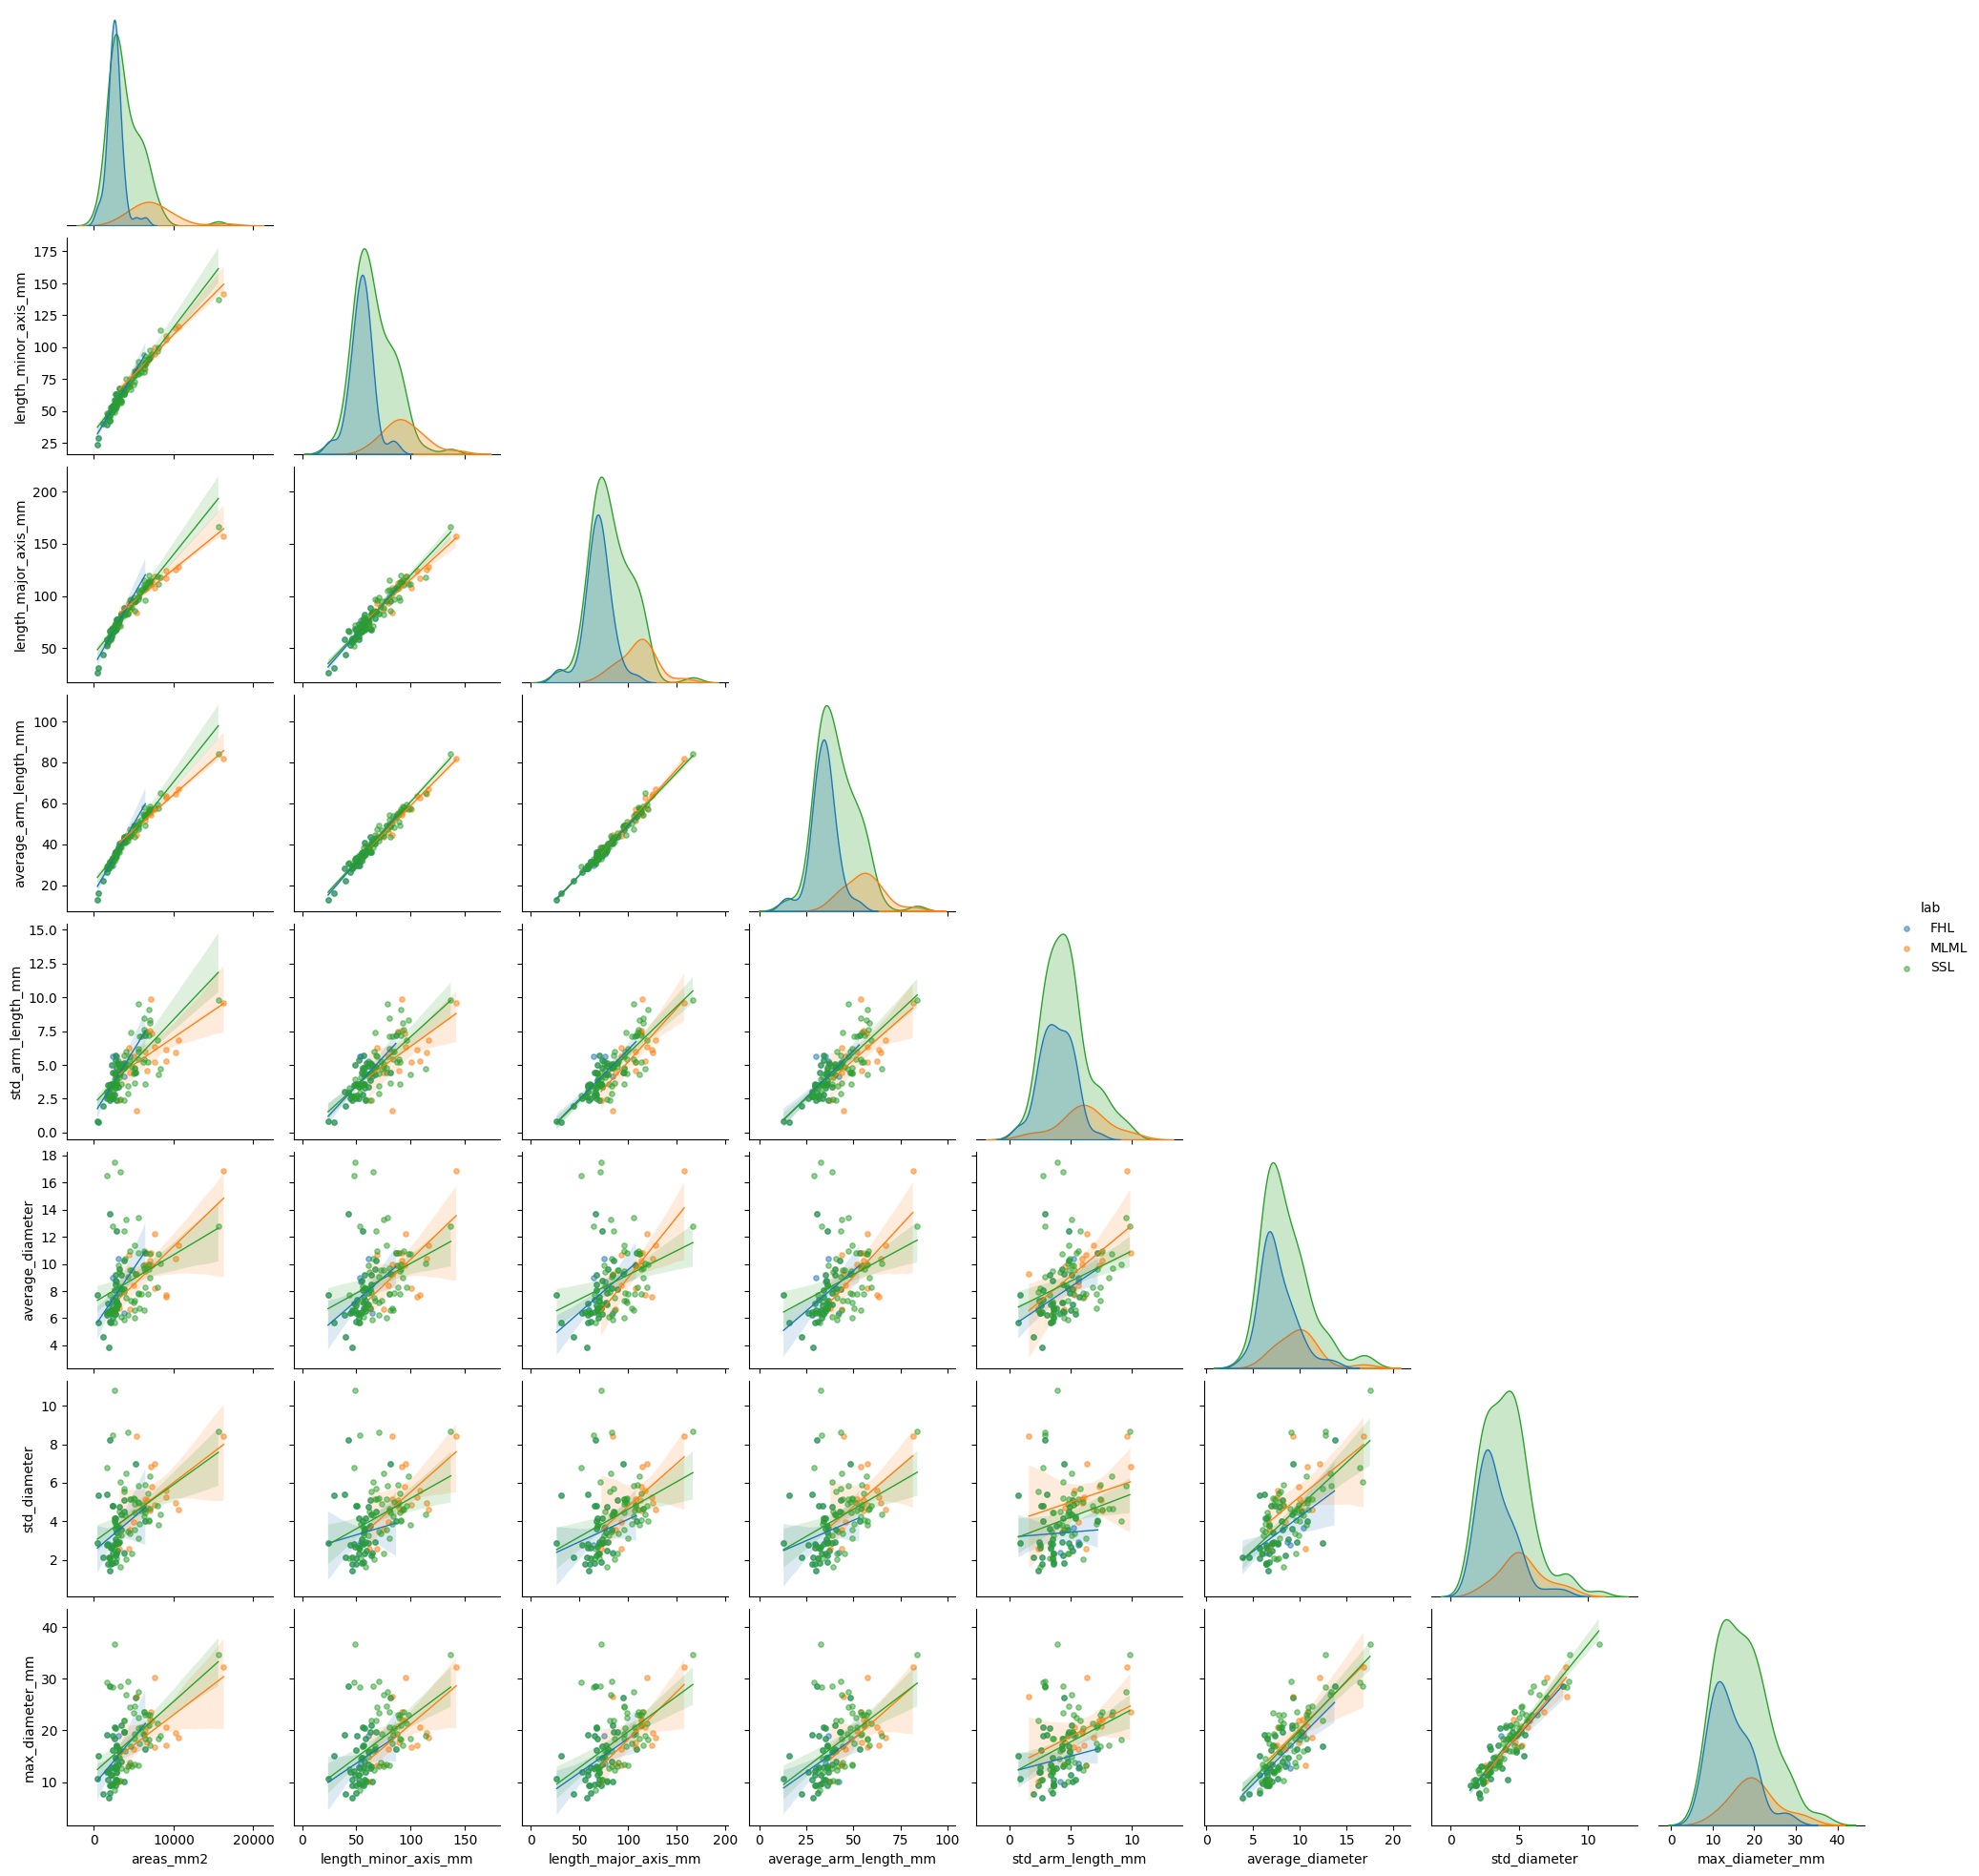

In [115]:
numeric_cols = [str(col) for col in data.columns[4:]]
sns.pairplot(
    data[numeric_cols + ['lab']],   # include lab for hue
    hue='lab',
    kind='reg',
    diag_kind='kde',
    corner=True,
    plot_kws={
        "scatter_kws": {"s": 15, "alpha": 0.5},  # smaller points, semi-transparent
        "line_kws": {"linewidth": 1}             # thinner regression lines
    }
)
plt.show()

FHL


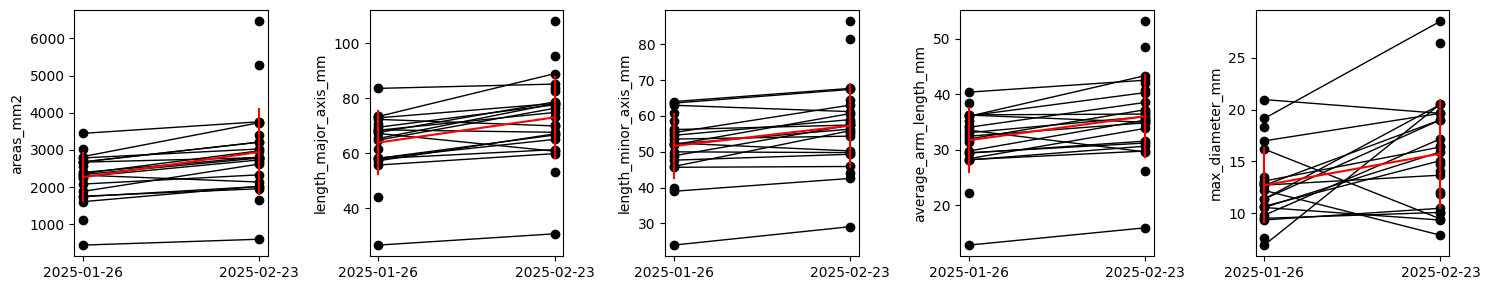

MLML


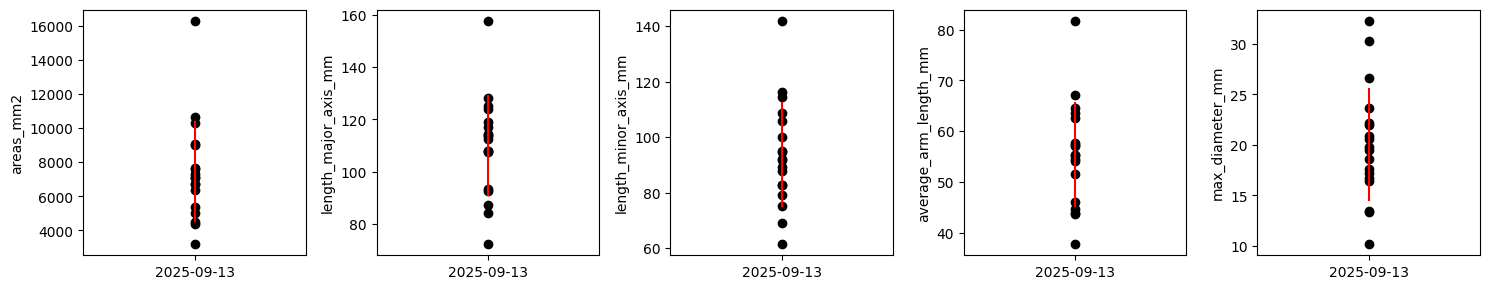

SSL


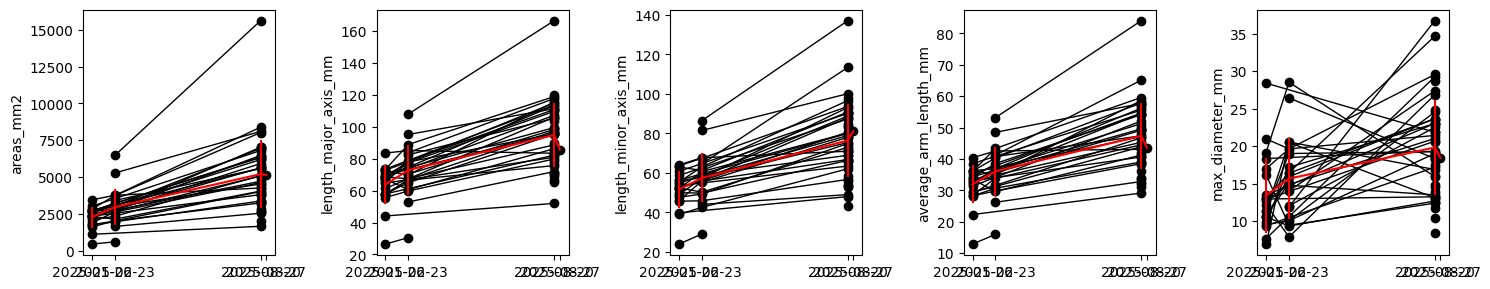

In [116]:
def plot_morphometric_parameter_by_date (ax, data, feature):
    xticks = []
    unique_dates = sorted(data['measurement_day'].unique())
    mean_value, std_value = [], []
    for date in unique_dates:
        xticks.append(date)
        tmp = data[data['measurement_day'] == date]
        values = tmp[feature]
        mean_value.append(np.mean(values))
        std_value.append(np.std(values))
    for id in data['id'].unique():
        for date in unique_dates:
            tmp = data[(data['measurement_day'] == date) & (data['id'] == id)]
            if len(tmp) != 1:
                continue
            ax.scatter(date, tmp[feature], color='black')
        tmp = data[data['id'] == id]
        if len(tmp) > 1:
            ax.plot(tmp['measurement_day'], tmp[feature], color='black', linewidth=1)
    ax.set_xticks(xticks)
    ax.set_ylabel(feature)
    
    ax.plot(unique_dates, mean_value, color='red')
    for date, mean, std in zip(unique_dates, mean_value, std_value):
        ax.plot([date, date], [mean-std, mean+std], color='red')

for name in measurement_dir_names:
    print(name)
    tmp = data[data['lab'] == name]

    fig, axs = plt.subplots(1,5,figsize=(15,3))
    
    plot_morphometric_parameter_by_date (axs[0], tmp, 'areas_mm2')
    plot_morphometric_parameter_by_date (axs[1], tmp, 'length_major_axis_mm')
    plot_morphometric_parameter_by_date (axs[2], tmp, 'length_minor_axis_mm')
    plot_morphometric_parameter_by_date (axs[3], tmp, 'average_arm_length_mm')
    plot_morphometric_parameter_by_date (axs[4], tmp, 'max_diameter_mm')
    
    fig.tight_layout()
    plt.show()

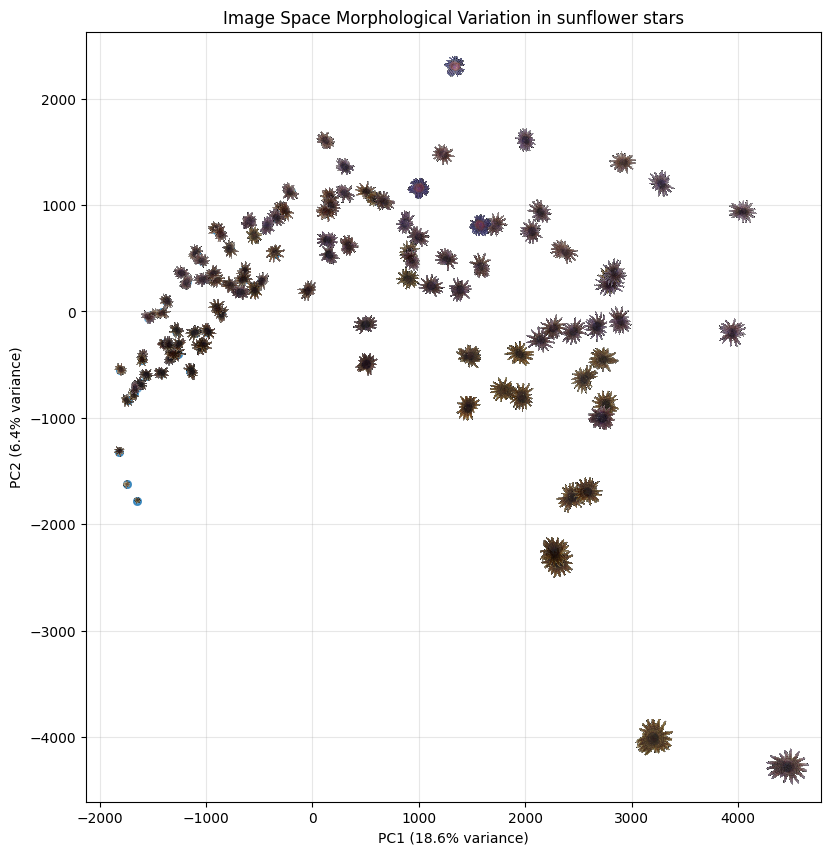

In [117]:
from src.starMorphometricTool.utils.visualization_utils import visualize_pca_with_images

fig, ax, X_pca, pca = visualize_pca_with_images(
    normalized_objects,
    max_thumbnails=200,    # Show up to 200 images
    max_image_size=0.2,  # Thumbnails take up 3% of plot area max
    fig_size=(10,10),    # Figure dimensions
    alpha=0.9,            # Transparency
    marker_size=30,        # Size of the scatter points,
    min_dist_factor=0.02,
    title="Image Space Morphological Variation in sunflower stars"
)


Explained variance by principal components:
PC1: 91.58%
PC2: 6.94%

Component loadings:
                            PC1       PC2
areas_mm2              0.453734 -0.293653
length_minor_axis_mm   0.456374 -0.287658
length_major_axis_mm   0.463147 -0.017586
average_arm_length_mm  0.462441 -0.177557
std_arm_length_mm      0.396852  0.893972


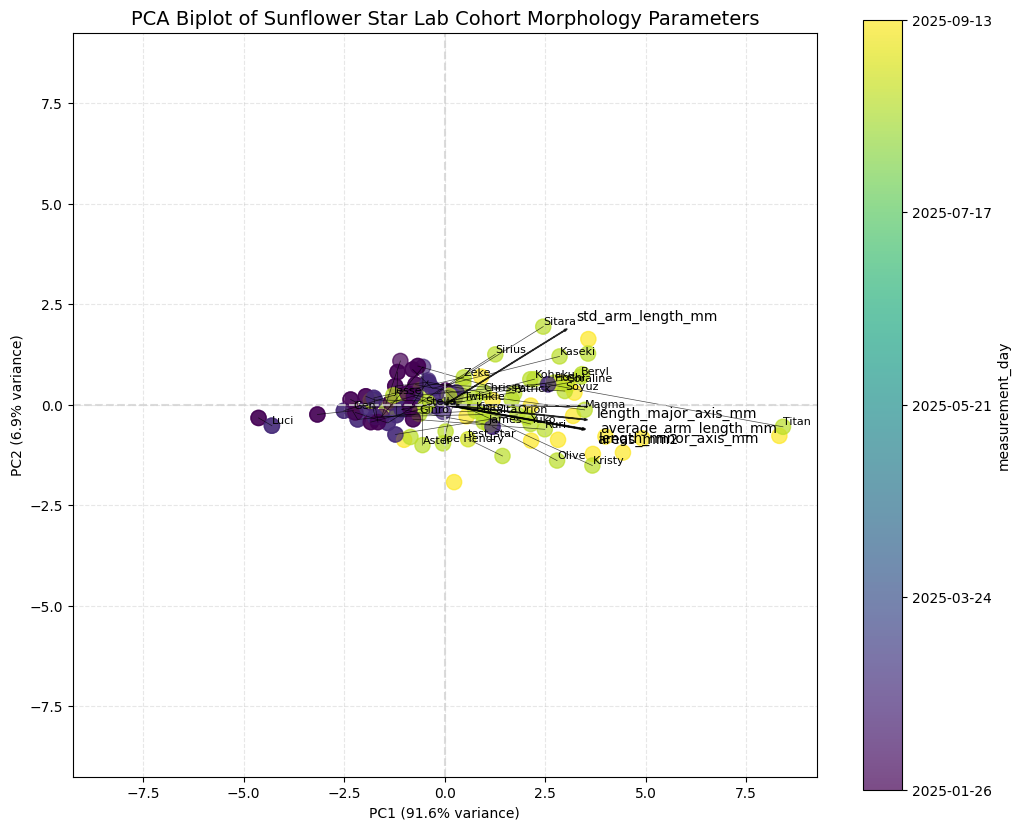

In [118]:
from src.starMorphometricTool.utils.morphology_pca import (compute_morphology_pca, create_pca_biplot)

# Select the features you want to include in the PCA
features = ['areas_mm2', 'length_minor_axis_mm', 'length_major_axis_mm', 
           'average_arm_length_mm', 'std_arm_length_mm']
# Compute the PCA
pca_df, pca_model, scaler, feature_names = compute_morphology_pca(data, columns=features)

# Create the biplot
fig, ax = create_pca_biplot(
    pca_df=pca_df,
    pca_model=pca_model,
    feature_names=feature_names,
    color_by='measurement_day',
    connect_by='id',              # Connect points with the same ID (was marker_by)
    title="PCA Biplot of Sunflower Star Lab Cohort Morphology Parameters",
    scaling=0.5,                  # Scale the arrows
    arrow_scale=7,                # Further scale up arrows
    arrow_color='black',          # All arrows are black
    marker_size=120,              # Larger markers
    line_color='black',           # Color for connecting lines
    line_width=0.5                # Thin lines connecting points
)

In [119]:

for lab in measurement_dir_names:
    print(f'{lab}')
    tmp = data[data['lab'] == lab]

    latest_day = tmp['measurement_day'].max()
    print(f'last measurement day {latest_day}')


FHL
last measurement day 2025-02-23 00:00:00
MLML
last measurement day 2025-09-13 00:00:00
SSL
last measurement day 2025-08-27 00:00:00


In [120]:
rank_value = 'areas_mm2'

data['measurement_day'] = pd.to_datetime(data['measurement_day'], errors='coerce')
last_per_id = (
    data.sort_values(['id', 'measurement_day'])     # oldest -> newest within each id
      .drop_duplicates(subset=['id', 'lab'], keep='last')  # keep most recent per id
      .sort_values(rank_value, ascending=False)      # rank order by value
)
last_per_id['rank'] = last_per_id[rank_value].rank(ascending=False, method='dense')
last_per_id = last_per_id[data.columns].reset_index(drop=True)
last_per_id

,lab,id,measurement_day,morphometrics_path,areas_mm2,length_minor_axis_mm,length_major_axis_mm,average_arm_length_mm,std_arm_length_mm,average_diameter,std_diameter,max_diameter_mm
0,MLML,1,2025-09-13,../../measurements/MLML/knownID\1\09_13_2025\m...,16288.491215,141.934228,157.662715,81.693007,9.568714,16.845622,8.426020,32.283721
1,SSL,Titan,2025-08-20,../../measurements/SSL/knownID\Titan\08_20_202...,15619.593745,136.993741,166.559990,84.032688,9.804412,12.762995,8.664608,34.682748
2,MLML,2,2025-09-13,../../measurements/MLML/knownID\2\09_13_2025\m...,10663.576516,116.273877,128.210426,67.106394,6.831146,11.362585,4.584997,18.625017
3,MLML,3,2025-09-13,../../measurements/MLML/knownID\3\09_13_2025\m...,10295.894379,114.476548,124.938912,64.634417,5.887995,10.408860,4.963505,19.497607
4,MLML,12,2025-09-13,../../measurements/MLML/knownID\12\09_13_2025\...,9078.587105,105.873883,123.870246,63.593522,6.115054,7.549523,5.231862,17.219509
...,...,...,...,...,...,...,...,...,...,...,...,...
90,SSL,Gen,2025-08-20,../../measurements/SSL/knownID\Gen\08_20_2025\...,1651.179326,48.010441,52.001893,29.132547,2.752014,16.480950,6.796059,29.259847
91,FHL,Jesse,2025-02-23,../../measurements/FHL/knownID\Jesse\02_23_202...,1643.072533,44.051336,52.953773,26.205136,2.542625,6.390081,2.789650,11.890149
92,FHL,Gen,2025-01-26,../../measurements/FHL/knownID\Gen\01_26_2025\...,1107.866822,39.770494,44.151993,22.285347,1.962880,4.589441,2.109310,7.653737
93,FHL,Luci,2025-02-23,../../measurements/FHL/knownID\Luci\02_23_2025...,597.751275,29.077222,30.605369,15.976245,0.746101,5.695481,5.328754,15.075812


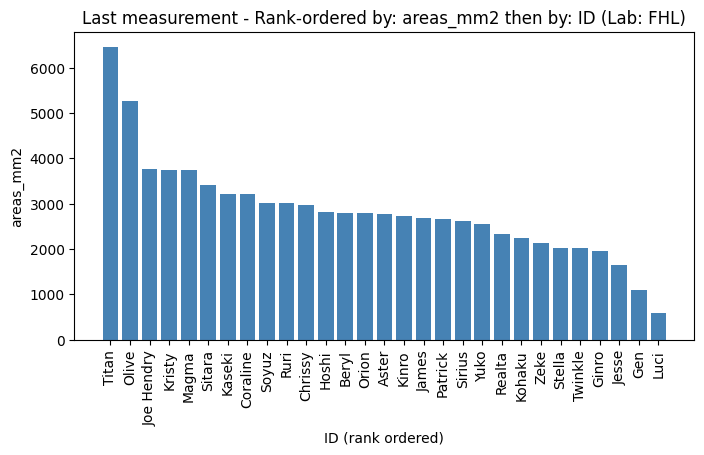

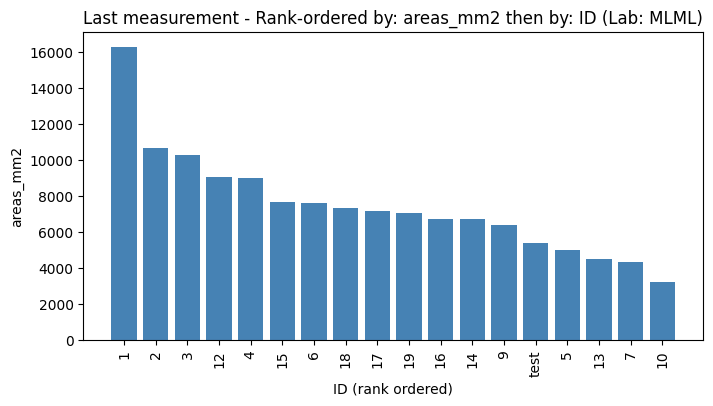

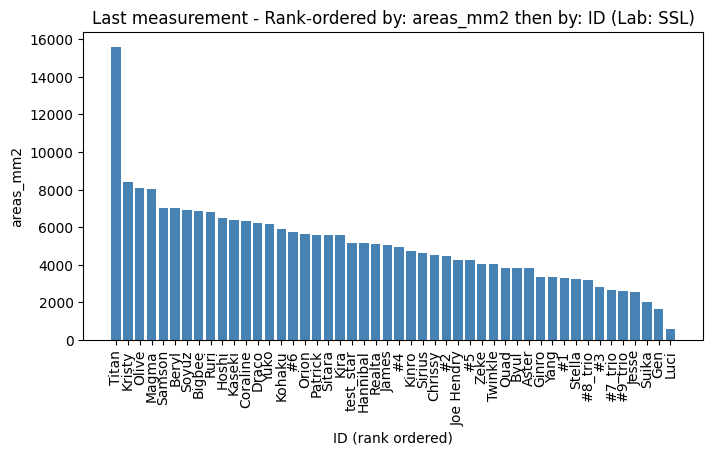

In [121]:

for lab in measurement_dir_names:
    
    fig, ax = plt.subplots(1,1,figsize=(8,4))
    
    tmp = last_per_id[last_per_id['lab'] == lab].sort_values(rank_value, ascending=False)
    
    # bar plot
    ax.bar(tmp['id'].astype(str), tmp[rank_value], color="steelblue")

    # make it readable
    ax.set_title(f"Last measurement - Rank-ordered by: {rank_value} then by: ID (Lab: {lab})")
    ax.set_xlabel("ID (rank ordered)")
    ax.set_ylabel(rank_value)
    ax.set_xticks(range(len(tmp)))
    ax.set_xticklabels(tmp['id'], rotation=90)
    
    plt.show()
    plt.close()
    